# AI-Based Image Classification System Using Deep Learning
### Mini Project

**Objective:** Perform image preprocessing, build and train a CNN model, explore Transfer Learning using pretrained models, evaluate model performance, and additionally demonstrate LSTM-based sentiment analysis and a Hugging Face pipeline.

**Dataset:** CIFAR-10 (loaded via `tensorflow.keras.datasets.cifar10`, which is the same official dataset distributed at https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz)

**Contents:**
1. Task 1 – Data Preparation
2. Task 2 – CNN Model Development
3. Task 3 – Transfer Learning (MobileNetV2)
4. Task 4 – Prediction and Visualization
5. Task 5 – Model Analysis and Documentation
6. LSTM-based Sentiment Analysis (IMDB dataset)
7. Hugging Face Pipeline Demo


In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn transformers --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Task 1 – Data Preparation

Load the CIFAR-10 dataset, explore it, normalize pixel values, split into train/test, visualize sample images, and handle class labels.

In [3]:
# Load the CIFAR-10 dataset (official dataset, same source as the .tar.gz distribution)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1728s 10us/step
Train shape: (50000, 32, 32, 3) (50000, 1)
Test shape: (10000, 32, 32, 3) (10000, 1)


In [4]:
# Explore the dataset - check class distribution
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{class_names[u]}: {c} images")

airplane: 5000 images
automobile: 5000 images
bird: 5000 images
cat: 5000 images
deer: 5000 images
dog: 5000 images
frog: 5000 images
horse: 5000 images
ship: 5000 images
truck: 5000 images


In [5]:
# Normalize pixel values to range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten labels from (N,1) to (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Normalized pixel range:", x_train.min(), "-", x_train.max())

Normalized pixel range: 0.0 - 1.0


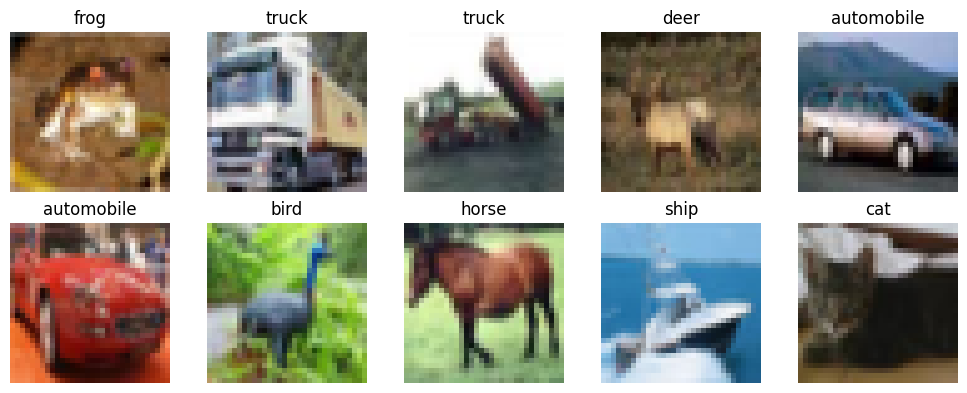

In [6]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Train-Test split is already provided by CIFAR-10 (x_train/y_train, x_test/y_test)
# We further split a validation set from the training data
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

Train: (45000, 32, 32, 3) Val: (5000, 32, 32, 3) Test: (10000, 32, 32, 3)


## Task 2 – CNN Model Development

Build a CNN with Convolution, MaxPooling, Dropout, Flatten, Dense and Softmax layers.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

cnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the CNN model
# NOTE: epochs=10 is a reasonable default for a mini-project; increase for higher accuracy.
cnn_history = cnn_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 118s 163ms/step - accuracy: 0.3620 - loss: 1.7304 - val_accuracy: 0.4922 - val_loss: 1.3836
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 114s 161ms/step - accuracy: 0.5128 - loss: 1.3536 - val_accuracy: 0.5976 - val_loss: 1.1542
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 158ms/step - accuracy: 0.5752 - loss: 1.1986 - val_accuracy: 0.6364 - val_loss: 1.0261
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 159ms/step - accuracy: 0.6122 - loss: 1.0922 - val_accuracy: 0.6878 - val_loss: 0.9028
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 115s 163ms/step - accuracy: 0.6376 - loss: 1.0271 - val_accuracy: 0.6936 - val_loss: 0.8777
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 113s 160ms/step - accuracy: 0.6620 - loss: 0.9680 - val_accuracy: 0.6998 - val_loss: 0.8801
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 161ms/step - accuracy: 0.6772 - loss: 0.9249 - val_accuracy: 0.7226 - val_loss: 0.7980
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 163ms/step - accuracy: 0.6873 -

In [10]:
# Evaluate the CNN model
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"CNN Test Loss: {cnn_test_loss:.4f}")

cnn_preds = np.argmax(cnn_model.predict(x_test), axis=1)

print("\nClassification Report (CNN):\n")
print(classification_report(y_test, cnn_preds, target_names=class_names))

CNN Test Accuracy: 0.7376
CNN Test Loss: 0.7525
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step

Classification Report (CNN):

              precision    recall  f1-score   support

    airplane       0.82      0.71      0.76      1000
  automobile       0.87      0.88      0.88      1000
        bird       0.63      0.60      0.61      1000
         cat       0.54      0.54      0.54      1000
        deer       0.64      0.72      0.68      1000
         dog       0.68      0.60      0.64      1000
        frog       0.75      0.83      0.79      1000
       horse       0.81      0.78      0.79      1000
        ship       0.80      0.90      0.85      1000
       truck       0.85      0.81      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



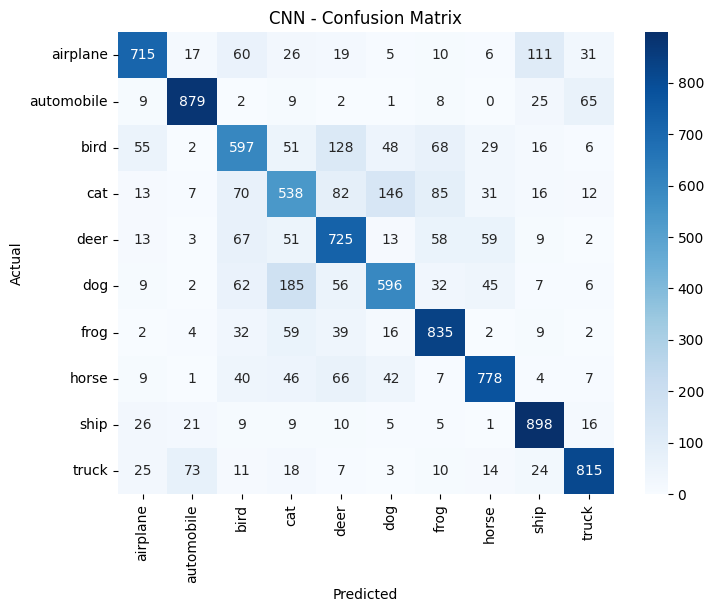

In [11]:
# Confusion Matrix - CNN
cnn_cm = confusion_matrix(y_test, cnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('CNN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Task 3 – Transfer Learning (MobileNetV2)

Load a pretrained MobileNetV2 (trained on ImageNet), freeze its base layers, add a custom classifier head, and train on CIFAR-10. CIFAR-10 images are resized to 96x96 to satisfy MobileNetV2's minimum input size.

In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 96

def resize_and_preprocess(images):
    resized = tf.image.resize(images, (IMG_SIZE, IMG_SIZE))
    return preprocess_input(resized * 255.0)  # undo earlier /255 normalization, then apply MobileNetV2 preprocessing

# Build tf.data pipelines to avoid loading all resized images into memory at once
def make_dataset(x, y, batch_size=64, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(2000)
    ds = ds.batch(batch_size)
    ds = ds.map(lambda img, lbl: (resize_and_preprocess(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(x_train, y_train, shuffle=True)
val_ds = make_dataset(x_val, y_val)
test_ds = make_dataset(x_test, y_test)

In [13]:
# Load pretrained MobileNetV2 (without top layer) and freeze base layers
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze base layers

# Add custom classifier on top
tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

tl_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train the transfer learning model
tl_history = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 365s 503ms/step - accuracy: 0.7962 - loss: 0.6050 - val_accuracy: 0.8450 - val_loss: 0.4473
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 383s 504ms/step - accuracy: 0.8520 - loss: 0.4322 - val_accuracy: 0.8676 - val_loss: 0.3876
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 363s 516ms/step - accuracy: 0.8672 - loss: 0.3819 - val_accuracy: 0.8712 - val_loss: 0.3904
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 347s 493ms/step - accuracy: 0.8795 - loss: 0.3476 - val_accuracy: 0.8744 - val_loss: 0.3732
Epoch 5/5


In [18]:
# Evaluate the Transfer Learning model
tl_test_loss, tl_test_acc = tl_model.evaluate(test_ds, verbose=0)
print(f"Transfer Learning Test Accuracy: {tl_test_acc:.4f}")
print(f"Transfer Learning Test Loss: {tl_test_loss:.4f}")

tl_preds = np.argmax(tl_model.predict(test_ds), axis=1)

print("\nClassification Report (Transfer Learning - MobileNetV2):\n")
print(classification_report(y_test, tl_preds, target_names=class_names))

Transfer Learning Test Accuracy: 0.8656
Transfer Learning Test Loss: 0.3911
157/157 ━━━━━━━━━━━━━━━━━━━━ 75s 476ms/step

Classification Report (Transfer Learning - MobileNetV2):

              precision    recall  f1-score   support

    airplane       0.83      0.91      0.87      1000
  automobile       0.96      0.90      0.93      1000
        bird       0.87      0.81      0.84      1000
         cat       0.77      0.74      0.75      1000
        deer       0.81      0.87      0.84      1000
         dog       0.86      0.77      0.82      1000
        frog       0.86      0.91      0.89      1000
       horse       0.88      0.88      0.88      1000
        ship       0.94      0.91      0.92      1000
       truck       0.88      0.95      0.91      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [ ]:
# Confusion Matrix - Transfer Learning
tl_cm = confusion_matrix(y_test, tl_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(tl_cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Transfer Learning (MobileNetV2) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Compare CNN vs Transfer Learning
print("Model Comparison")
print(f"{'Model':<25}{'Test Accuracy':<15}{'Test Loss':<10}")
print(f"{'Custom CNN':<25}{cnn_test_acc:<15.4f}{cnn_test_loss:<10.4f}")
print(f"{'MobileNetV2 (TL)':<25}{tl_test_acc:<15.4f}{tl_test_loss:<10.4f}")

## Task 4 – Prediction and Visualization

Predict unseen test images, display actual vs predicted labels, visualize correctly classified and misclassified images, and plot accuracy/loss curves.

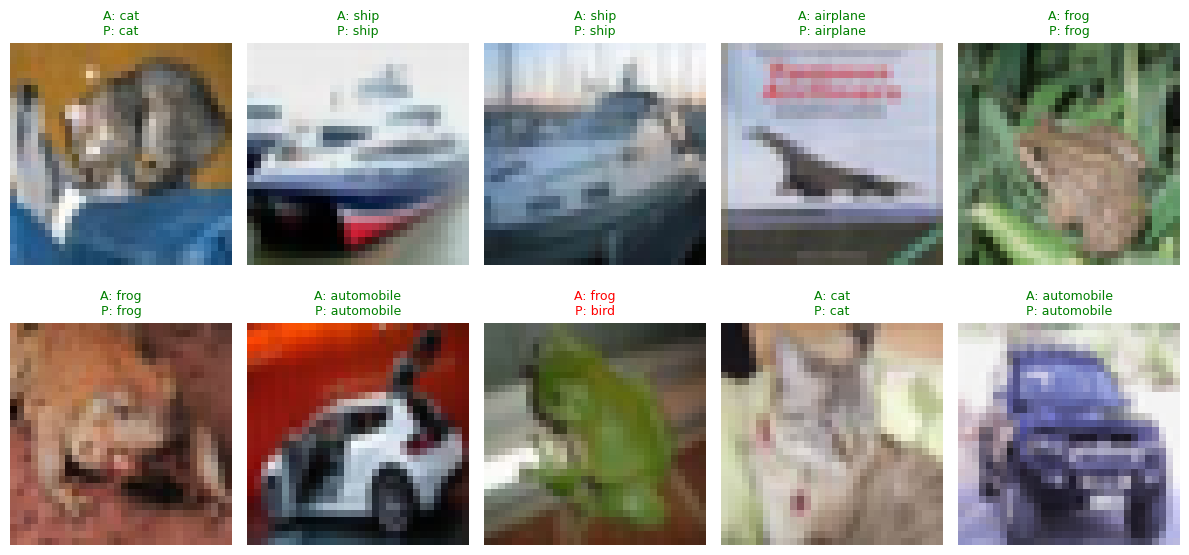

In [19]:
# Display actual vs predicted labels for a few test images (using CNN predictions)
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])
    color = 'green' if cnn_preds[i] == y_test[i] else 'red'
    plt.title(f"A: {class_names[y_test[i]]}\nP: {class_names[cnn_preds[i]]}", color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

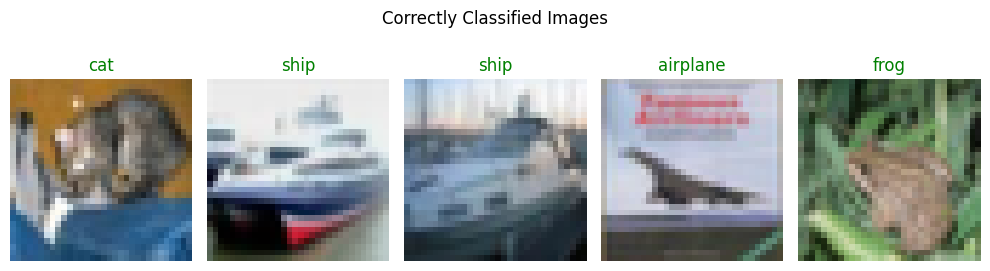

In [20]:
# Visualize correctly classified images
correct_idx = np.where(cnn_preds == y_test)[0][:5]
plt.figure(figsize=(10, 3))
for i, idx in enumerate(correct_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"{class_names[y_test[idx]]}", color='green')
    plt.axis('off')
plt.suptitle("Correctly Classified Images")
plt.tight_layout()
plt.show()

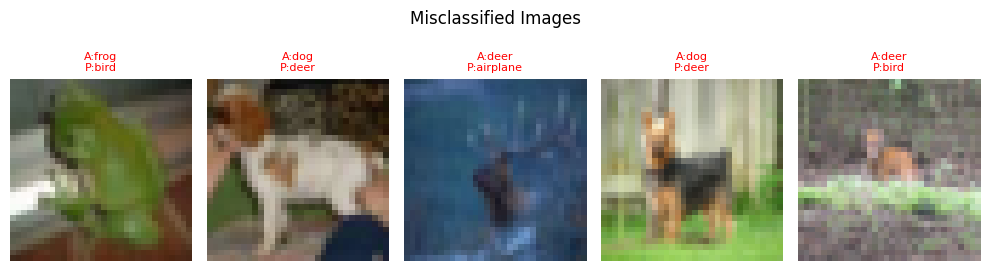

In [21]:
# Visualize misclassified images
wrong_idx = np.where(cnn_preds != y_test)[0][:5]
plt.figure(figsize=(10, 3))
for i, idx in enumerate(wrong_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"A:{class_names[y_test[idx]]}\nP:{class_names[cnn_preds[idx]]}", color='red', fontsize=8)
    plt.axis('off')
plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()

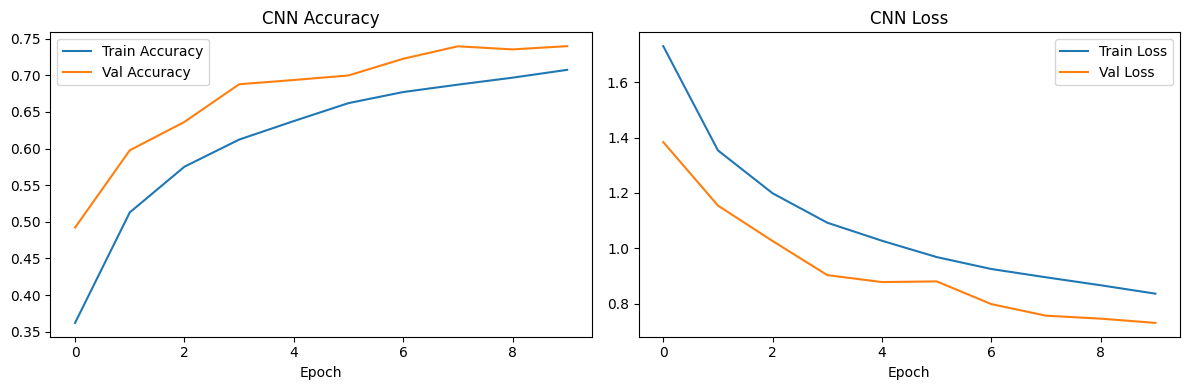

In [22]:
# Plot training and validation accuracy/loss - CNN
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(cnn_history.history['accuracy'], label='Train Accuracy')
ax[0].plot(cnn_history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('CNN Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(cnn_history.history['loss'], label='Train Loss')
ax[1].plot(cnn_history.history['val_loss'], label='Val Loss')
ax[1].set_title('CNN Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.show()

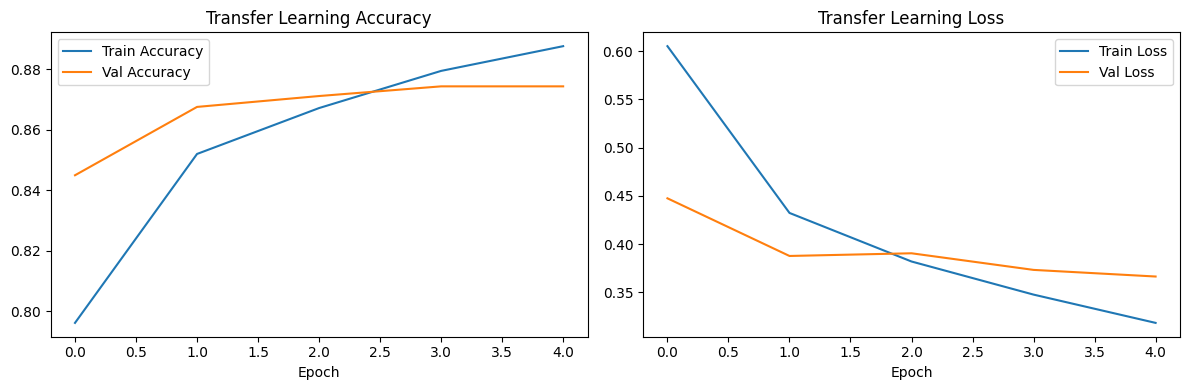

In [23]:
# Plot training and validation accuracy/loss - Transfer Learning
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(tl_history.history['accuracy'], label='Train Accuracy')
ax[0].plot(tl_history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Transfer Learning Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(tl_history.history['loss'], label='Train Loss')
ax[1].plot(tl_history.history['val_loss'], label='Val Loss')
ax[1].set_title('Transfer Learning Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.show()

## Task 5 – Model Analysis and Documentation

**Comparison between CNN and Transfer Learning**
- The custom CNN is trained from scratch on CIFAR-10 only, so it needs more epochs/data to reach high accuracy.
- The Transfer Learning model (MobileNetV2) reuses features learned from ImageNet (millions of images), so it can reach reasonable accuracy faster with fewer epochs, even though CIFAR-10 images are small and need upscaling.

**Advantages and Limitations**

| Approach | Advantages | Limitations |
|---|---|---|
| Custom CNN | Full control over architecture; no dependency on external pretrained weights | Needs more data/epochs; longer training time for high accuracy |
| Transfer Learning | Faster convergence; leverages large-scale pretrained features; good with limited data | Base model was trained on different image types (ImageNet); requires resizing small CIFAR-10 images; less flexible if the base architecture doesn't fit the domain |

**Challenges Faced**
- CIFAR-10 images (32x32) are much smaller than what pretrained ImageNet models expect, requiring resizing (which adds compute overhead and can introduce blurring).
- Training deep learning models is compute/time intensive, especially without a GPU.
- Balancing overfitting vs underfitting required tuning Dropout and epochs.

**Real-World Applications**
- Quality inspection in manufacturing, medical image diagnosis, retail product categorization, security surveillance, autonomous vehicles.

**Future Improvements**
- Use data augmentation (rotation, flip, zoom) to improve generalization.
- Fine-tune (unfreeze) some top layers of the pretrained base model.
- Try other pretrained architectures (ResNet50, EfficientNetB0) and compare.
- Train for more epochs with learning rate scheduling.


## LSTM-Based Sentiment Analysis (IMDB Dataset)

A separate, simple deep learning task: sentiment analysis of movie reviews using an LSTM built from scratch (not a pretrained model), using Keras' built-in IMDB dataset.

In [24]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 10000
MAX_LEN = 200

(x_train_text, y_train_text), (x_test_text, y_test_text) = imdb.load_data(num_words=VOCAB_SIZE)

x_train_text = pad_sequences(x_train_text, maxlen=MAX_LEN)
x_test_text = pad_sequences(x_test_text, maxlen=MAX_LEN)

print("Train:", x_train_text.shape, "Test:", x_test_text.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (25000, 200) Test: (25000, 200)


In [25]:
lstm_model = models.Sequential([
    layers.Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
    layers.LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
lstm_history = lstm_model.fit(
    x_train_text, y_train_text,
    validation_split=0.1,
    epochs=3,
    batch_size=128
)

Epoch 1/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 79s 424ms/step - accuracy: 0.7328 - loss: 0.5339 - val_accuracy: 0.8024 - val_loss: 0.4338
Epoch 2/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 69s 390ms/step - accuracy: 0.8495 - loss: 0.3617 - val_accuracy: 0.8284 - val_loss: 0.3867
Epoch 3/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 71s 404ms/step - accuracy: 0.8779 - loss: 0.3048 - val_accuracy: 0.7904 - val_loss: 0.4567


In [27]:
lstm_loss, lstm_acc = lstm_model.evaluate(x_test_text, y_test_text, verbose=0)
print(f"LSTM Test Accuracy: {lstm_acc:.4f}")
print(f"LSTM Test Loss: {lstm_loss:.4f}")

lstm_preds = (lstm_model.predict(x_test_text) > 0.5).astype(int).flatten()
print("\nClassification Report (LSTM Sentiment Analysis):\n")
print(classification_report(y_test_text, lstm_preds, target_names=['negative', 'positive']))

LSTM Test Accuracy: 0.7904
LSTM Test Loss: 0.4480
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step

Classification Report (LSTM Sentiment Analysis):

              precision    recall  f1-score   support

    negative       0.88      0.68      0.76     12500
    positive       0.74      0.90      0.81     12500

    accuracy                           0.79     25000
   macro avg       0.81      0.79      0.79     25000
weighted avg       0.81      0.79      0.79     25000



## Hugging Face Pipeline Implementation

A quick demonstration using a pretrained Hugging Face model for sentiment analysis, for comparison with the LSTM model trained from scratch above.

In [28]:
from transformers import pipeline

hf_classifier = pipeline("sentiment-analysis")

sample_reviews = [
    "This movie was absolutely fantastic, I loved every second of it!",
    "Terrible plot and bad acting, total waste of time.",
    "It was an okay movie, nothing special but watchable."
]

hf_results = hf_classifier(sample_reviews)

for review, result in zip(sample_reviews, hf_results):
    print(f"Review: {review}\n  --> {result['label']} (score: {result['score']:.4f})\n")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Review: This movie was absolutely fantastic, I loved every second of it!
  --> POSITIVE (score: 0.9999)

Review: Terrible plot and bad acting, total waste of time.
  --> NEGATIVE (score: 0.9998)

Review: It was an okay movie, nothing special but watchable.
  --> POSITIVE (score: 0.9981)



## Conclusion

This mini-project covered the complete deep learning workflow:
- Built and evaluated a custom **CNN** for CIFAR-10 image classification.
- Applied **Transfer Learning** with MobileNetV2 and compared it against the custom CNN.
- Visualized predictions, correct/incorrect classifications, and training curves.
- Built an **LSTM** model from scratch for text sentiment analysis on the IMDB dataset.
- Used a **Hugging Face pretrained pipeline** for the same sentiment task, without training, for comparison.

Together these demonstrate both training models from scratch and reusing pretrained models — the two core approaches in modern deep learning.